<a href="https://colab.research.google.com/github/Lagnadeep-samal/Machine-learning-models/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sample_data = np.array([
    [3, 7],
    [-4, -6],
    [1, -1],
    [7, 8],
    [-4, -1],
    [-3, -7]
])

In [3]:
dataframe = pd.DataFrame(sample_data, columns=['x', 'y'])

In [4]:
dataframe.describe()

,x,y
count,6.000000,6.000000
mean,0.000000,0.000000
std,4.472136,6.324555
min,-4.000000,-7.000000
25%,-3.750000,-4.750000
50%,-1.000000,-1.000000
75%,2.500000,5.000000
max,7.000000,8.000000


In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
dataframe_scaled=scaler.fit_transform(dataframe)

In [9]:
dataframe_scaled = pd.DataFrame(
    data=dataframe_scaled,
    columns=['feature1', 'feature2']
)

In [10]:
dataframe_scaled.describe()

,feature1,feature2
count,6.000000e+00,6.000000
mean,1.850372e-17,0.000000
std,1.095445e+00,1.095445
min,-9.797959e-01,-1.212436
25%,-9.185587e-01,-0.822724
50%,-2.449490e-01,-0.173205
75%,6.123724e-01,0.866025
max,1.714643e+00,1.385641


In [11]:
covariance_matrix = dataframe_scaled.T @ dataframe_scaled / 5
covariance_matrix

,feature1,feature2
feature1,1.20000,1.06066
feature2,1.06066,1.20000


In [12]:
eigenValue, eigenVectors = np.linalg.eig(covariance_matrix)

In [13]:
print("Eigen Values:")
print(eigenValue)

print("\nEigen Vectors:")
print(eigenVectors)

Eigen Values:
[2.26066017 0.13933983]

Eigen Vectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [15]:
pc1=dataframe_scaled @ eigenVectors[:, 0]
pc1

,0
0,1.376937
1,-1.427667
2,0.050731
3,2.192231
4,-0.815295
5,-1.376937


In [16]:
pc2=dataframe_scaled @ eigenVectors[:, 1]
pc2

,0
0,0.337706
1,-0.042027
2,-0.295680
3,-0.232640
4,0.570346
5,-0.337706


In [26]:
# with dataset implementation

In [17]:
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

In [19]:
#SNF
scaler=StandardScaler()
X_scaler=scaler.fit_transform(X)

In [20]:
from sklearn.decomposition import PCA
pca=PCA()
x_pca=pca.fit_transform(X_scaler)

In [21]:
evr = pca.explained_variance_ratio_
print(evr)

[0.72962445 0.22850762 0.03668922 0.00517871]


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=44
)

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
pipeline=Pipeline([
    ('scaler',StandardScaler()),
    ('pca',PCA(n_components=0.95)),
    ('model',LogisticRegression())]

)

In [25]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)),
                ('model', LogisticRegression())])

In [27]:
y_pred=pipeline.predict(X_test)


In [28]:
from sklearn.metrics import confusion_matrix,accuracy_score
accuracy_score(y_test,y_pred)



0.8

In [29]:
confusion_matrix(y_test,y_pred)

array([[9, 0, 0],
       [0, 7, 2],
       [0, 4, 8]])

In [32]:
print(pipeline.named_steps['pca'].n_components_)

2


In [33]:
print(pipeline.named_steps['pca'].explained_variance_ratio_)

[0.73080738 0.22959504]


In [34]:
print(pipeline.named_steps['pca'].explained_variance_ratio_.sum())

0.9604024137220873


In [35]:
X_train_pca = pipeline.named_steps['pca'].transform(
    pipeline.named_steps['scaler'].transform(X_train)
)

print(X_train_pca[:3])

[[-2.18825461  0.94097223]
 [ 0.62750273 -0.1713279 ]
 [ 0.29486801 -0.61555587]]


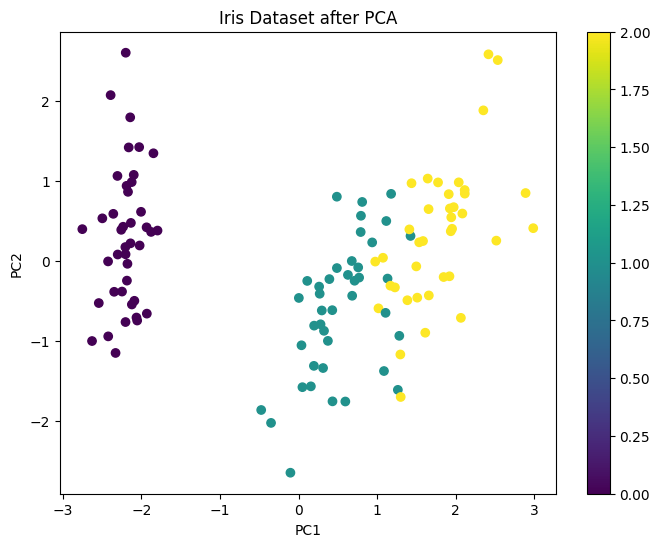

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Iris Dataset after PCA")

plt.colorbar()

plt.show()